# Quantum Feature Augmentation for Financial Market Prediction - AWS X State Street
### YQuantum 2026 

| Section | What You'll Learn |
|---|---|
| 1. Setup | Environment and imports |
| 2. Quantum Approach | Quick reference for key quantum ML vocabulary |
| 3. Data Generation | Generate the simulated regime-switching market data |
| 4. Classical Baseline | Polynomial feature expansion + Linear Regression — your bar to beat |
| 5. Quantum Feature Maps | Encode classical data into quantum states using rotation & entangling gates |
| 6. Hybrid Workflows | Variational circuits as trainable feature transformers |
| 8. Dimensionality Reduction | Dealing with overfitting after feature augmentation |
| 9. Evaluation | Compare all approaches with consistent metrics |
| 10. Real Stock Data | Task 2 of the challenge |
| 11. Further Reading | Additional quantum feature engineering methods for a broader landscape |

(This notebook aims to be used as a reference for guiding your implementation.)

---
## 1. Environment Setup
We use **Amazon Braket SDK** for all quantum circuits. The `LocalSimulator` runs everything on your machine. When you're ready to scale, you can swap in a managed simulator or QPU with a one-line change.

Note: We recommend keeping in consideration the noise and shot-based circuit evaluations, and not be totally reliant on analytically evaluated quantum circuits for your conclusions

Link to Amazon Braket Documentation: [amazon-braket-documentation](https://docs.aws.amazon.com/braket/latest/developerguide/what-is-braket.html)

Amazon Braket Examples GitHub Repository
[amazon-braket-examples](https://github.com/amazon-braket/amazon-braket-examples)

In [1]:
# PROVIDED — install dependencies (run once)
# Uncomment the line below if you haven't installed these yet
# On Braket notebook instances, braket-sdk/numpy/matplotlib are pre-installed.
# Use %pip (not !pip) to ensure packages install into the active kernel environment.
# %pip install -q scipy scikit-learn pandas seaborn pennylane
# %pip install amazon-braket-sdk amazon-braket-pennylane-plugin 

In [50]:
import boto3

# Check your account ID
account_id = boto3.client("sts").get_caller_identity()["Account"]
region = boto3.session.Session().region_name
print(f"Account: {account_id}")
print(f"Region: {region}")

# Default Braket bucket name
default_bucket = f"amazon-braket-{region}-{account_id}"
print(f"Default bucket: {default_bucket}")

# Verify it exists
s3 = boto3.client("s3")
try:
    s3.head_bucket(Bucket=default_bucket)
    print("Bucket exists!")
except:
    print("Bucket not found — creating it...")
    s3.create_bucket(Bucket=default_bucket)

Account: 315581690104
Region: us-east-1
Default bucket: amazon-braket-us-east-1-315581690104
Bucket not found — creating it...


In [55]:
# Imports
    
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Classical Machine Learning
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# Quantum Machine Learning
import pennylane as qml
from pennylane import numpy as pnp

# Amazon Braket
from braket.circuits import Circuit, Observable, ResultType
from braket.devices import LocalSimulator

# Reproducibility
np.random.seed(42)

# Local state-vector simulator (exact, no shot noise)
SV_DEVICE = LocalSimulator("default")

# Setting up Amazon Braket Environment

N_QUBITS = 4  # One qubit per feature (X1, X2, X3, X4)

# Local Simulator
dev_braket_local = qml.device(
    "braket.local.qubit",
    wires=N_QUBITS,
    backend="default",  # Braket's local state vector simulator
)



# AWS Quantum Hardware
dev_braket = qml.device(
    "braket.aws.qubit",
    device_arn="arn:aws:braket:us-east-1::device/qpu/ionq/Forte-1",
    wires=N_QUBITS,
    s3_destination_folder=(default_bucket, "y_quantum_results"),
    shots=1000,
)
print("INIT SUCCESS")

INIT SUCCESS


## 2. Quantum Approach: Quick Reference

Here's the specific vocabulary we'll use throughout:

| Term | Meaning |
|---|---|
| **Feature map** | A quantum circuit that encodes a classical data point **x** into a quantum state \|φ(x)⟩. Different circuits create different encodings. |
| **Hilbert space** | The exponentially large state space of *n* qubits (dimension 2ⁿ). A 10-qubit system lives in a 1024-dimensional space. |
| **Variational circuit** | A parameterized quantum circuit where gate angles are *learned* during training, like weights in a neural network. |
| **Expectation value** | Measuring an observable (e.g., Pauli-Z) on a qubit gives a number in [-1, 1]. We use these as features. |

**Why might quantum features help for financial data?**

Financial signals are buried in noise, and the relationships between features can be highly non-linear (e.g., regime-dependent interactions). Quantum feature maps project data into an exponentially large Hilbert space where these non-linear relationships may become linearly separable — similar in spirit to the classical kernel trick, but accessing a fundamentally different class of feature spaces.

## 3. Data Generation - Simulated Regime Process

Refer the challenge spec: a two-regime process where Regime 1 (75% of the time) has one set of relationships and Regime 2 (25%) has a different set. 

In [45]:
def generate_regime_data(n_samples, seed=42):
    """
    Generate synthetic regime-switching data per the challenge spec.
    
    Returns:
        X: array of shape (n_samples, 4) — features X1, X2, X3, X4
        y: array of shape (n_samples,) — target variable
        regimes: array of shape (n_samples,) — 0 for Regime 1, 1 for Regime 2
    """
    rng = np.random.default_rng(seed)
    
    # Assign regimes: 75% Regime 1, 25% Regime 2
    regimes = rng.choice([0, 1], size=n_samples, p=[0.75, 0.25])
    
    n1 = np.sum(regimes == 0)
    n2 = np.sum(regimes == 1)
    
    X = np.zeros((n_samples, 4))
    y = np.zeros(n_samples)
    
    # --- Regime 1 ---
    mask1 = regimes == 0
    X[mask1, 0] = rng.standard_normal(n1)          # X1 ~ N(0,1)
    X[mask1, 1] = rng.standard_normal(n1)          # X2 ~ N(0,1)
    X[mask1, 2] = rng.standard_normal(n1)          # X3 ~ N(0,1)
    X[mask1, 3] = rng.uniform(-1, 1, size=n1)     # X4 ~ Uniform(-1,1)
    eps1 = rng.standard_normal(n1)                  # noise
    
    y[mask1] = 2 * X[mask1, 0] - X[mask1, 1] + eps1
    
    # --- Regime 2 ---
    mask2 = regimes == 1
    
    # X1 and X3 are jointly normal with correlation 0.8
    mean = [3, 3]
    cov = [[1, 0.8],
           [0.8, 1]]
    x1_x3 = rng.multivariate_normal(mean, cov, size=n2)
    X[mask2, 0] = x1_x3[:, 0]                      # X1
    X[mask2, 2] = x1_x3[:, 1]                      # X3
    
    # X2 ~ Cauchy(0,1)
    X[mask2, 1] = rng.standard_cauchy(size=n2)
    
    # X4 ~ Exponential(lambda=1)
    X[mask2, 3] = rng.exponential(scale=1.0, size=n2)
    
    eps2 = rng.standard_normal(n2)                  # noise
    
    y[mask2] = (X[mask2, 0] * X[mask2, 2]) + np.log(np.abs(X[mask2, 1]) + 1) + eps2
    
    return X, y, regimes


# Generate train and test sets
X_train, y_train, regimes_train = generate_regime_data(10000, seed=42)
X_test, y_test, regimes_test = generate_regime_data(10000, seed=123)

print(f"Train: X shape {X_train.shape}, y shape {y_train.shape}")
print(f"  Regime 1: {np.sum(regimes_train == 0)}, Regime 2: {np.sum(regimes_train == 1)}")
print(f"Test:  X shape {X_test.shape}, y shape {y_test.shape}")
print(f"  Regime 1: {np.sum(regimes_test == 0)}, Regime 2: {np.sum(regimes_test == 1)}")

# Quick sanity checks
print(f"\nTrain y — mean: {y_train.mean():.3f}, std: {y_train.std():.3f}")
print(f"Test  y — mean: {y_test.mean():.3f}, std: {y_test.std():.3f}")
print(f"\nRegime 2 X2 (Cauchy) — min: {X_train[regimes_train==1, 1].min():.1f}, max: {X_train[regimes_train==1, 1].max():.1f}")

Train: X shape (10000, 4), y shape (10000,)
  Regime 1: 7558, Regime 2: 2442
Test:  X shape (10000, 4), y shape (10000,)
  Regime 1: 7633, Regime 2: 2367

Train y — mean: 2.633, std: 5.948
Test  y — mean: 2.597, std: 5.840

Regime 2 X2 (Cauchy) — min: -614.6, max: 4488.2


In [46]:
# Simulated Data Generation
def preprocess_features(X_train, X_test, clip_value=5.0):
    """
    Standardize and clip features for use with quantum circuits.
    
    Quantum rotation gates expect bounded inputs — unbounded values
    (especially from Cauchy-distributed X2) would wrap around and
    destroy meaningful encoding.
    
    Steps:
        1. Standardize (zero mean, unit variance) fit on train only
        2. Clip to [-clip_value, clip_value] to tame Cauchy outliers
        3. Rescale to [0, pi] for rotation gate compatibility
    
    Returns:
        X_train_processed, X_test_processed, scaler
    """
    # Step 1: Standardize (fit on train, transform both)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Step 2: Clip outliers
    X_train_s = np.clip(X_train_s, -clip_value, clip_value)
    X_test_s = np.clip(X_test_s, -clip_value, clip_value)
    
    # Step 3: Rescale to [0, pi] for quantum rotation gates
    X_train_q = (X_train_s + clip_value) / (2 * clip_value) * np.pi
    X_test_q = (X_test_s + clip_value) / (2 * clip_value) * np.pi
    
    return X_train_s, X_test_s, X_train_q, X_test_q, scaler


X_train_s, X_test_s, X_train_q, X_test_q, scaler = preprocess_features(X_train, X_test)

print("Standardized (for classical models):")
print(f"  Train — min: {X_train_s.min():.2f}, max: {X_train_s.max():.2f}")
print(f"  Test  — min: {X_test_s.min():.2f}, max: {X_test_s.max():.2f}")

print(f"\nQuantum-ready [0, pi]:")
print(f"  Train — min: {X_train_q.min():.4f}, max: {X_train_q.max():.4f}")
print(f"  Test  — min: {X_test_q.min():.4f}, max: {X_test_q.max():.4f}")

# Check how many values got clipped
n_clipped = np.sum(np.abs(X_train_s) == 5.0)
print(f"\nClipped values in train: {n_clipped} ({n_clipped / X_train_s.size * 100:.2f}%)")

Standardized (for classical models):
  Train — min: -5.00, max: 5.00
  Test  — min: -5.00, max: 5.00

Quantum-ready [0, pi]:
  Train — min: 0.0000, max: 3.1416
  Test  — min: 0.0000, max: 3.1416

Clipped values in train: 34 (0.08%)


## 4. Classical Baseline

Before touching any quantum circuit, establish a strong classical baseline. The challenge requires linear regression as the base model. Classically, We augment features with polynomial expansions (degree 2) - this gives the model access to all pairwise interactions (like x₁·x₃).

**Classical baseline is your bar to rigorously compare against**, If quantum features don't improve on this, that's a valid (and publishable) negative result.

In [47]:
# classical baseline with polynomial features
# This is a simple classical approach, feel free to extend this with classically researched methods for equally elevated comparisons

# NOTE: Example Code
# X_train_s, y_train etc are undefined in the example below

def evaluate_model(y_true, y_pred, label=""):
    """Compute standard regression metrics."""
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    corr = pearsonr(y_true, y_pred)[0]
    return {"model": label, "MSE": round(mse, 6), "MAE": round(mae, 6), "Corr": round(corr, 4)}


# --- Degree-1 (raw features) ---
lr_raw = LinearRegression().fit(X_train_s, y_train)
pred_raw = lr_raw.predict(X_test_s)
results_feature_maps = [evaluate_model(y_test, pred_raw, "LR (raw features)")]

# --- Degree-2 (polynomial features) ---
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train_s)
X_test_poly  = poly.transform(X_test_s)

lr_poly = LinearRegression().fit(X_train_poly, y_train)
pred_poly = lr_poly.predict(X_test_poly)
results_feature_maps.append(evaluate_model(y_test, pred_poly, "LR (poly deg=2)"))

# --- Ridge with poly (regularized) ---
ridge_poly = Ridge(alpha=1.0).fit(X_train_poly, y_train)
pred_ridge = ridge_poly.predict(X_test_poly)
results_feature_maps.append(evaluate_model(y_test, pred_ridge, "Ridge (poly deg=2)"))

# perform cross-validation to find a good alpha for Lasso regression on the polynomial features
lasso_cv = GridSearchCV(Lasso(max_iter=10000), param_grid={"alpha": [0.001, 0.01, 0.1, 1.0]}, cv=5)
lasso_cv.fit(X_train_poly, y_train)
print(f"Best alpha for Lasso (poly features): {lasso_cv.best_params_['alpha']}")
lasso_poly = Lasso(alpha=lasso_cv.best_params_['alpha'], max_iter=10000).fit(X_train_poly, y_train)
pred_lasso = lasso_poly.predict(X_test_poly)
results_feature_maps.append(evaluate_model(y_test, pred_lasso, "Lasso (poly deg=2)"))
# check the number of features that lasso kept non-zero
n_nonzero = np.sum(lasso_poly.coef_ != 0)
print(f"\nLasso selected {n_nonzero} features out of {X_train_poly.shape[1]} total features.")

baseline_df = pd.DataFrame(results_feature_maps)

print("=== Classical Baselines (Out-of-Sample) ===")
baseline_df


Best alpha for Lasso (poly features): 0.01

Lasso selected 12 features out of 14 total features.
=== Classical Baselines (Out-of-Sample) ===


,model,MSE,MAE,Corr
0,LR (raw features),4.566243,1.618328,0.9307
1,LR (poly deg=2),2.225732,1.155280,0.9669
2,Ridge (poly deg=2),2.220557,1.156471,0.9669
3,Lasso (poly deg=2),2.250492,1.194461,0.9665


## 5. Quantum Feature Maps

A **quantum feature map** is a circuit that transforms a classical vector **x** into a quantum state |φ(**x**)⟩. The key idea: by measuring this state, we extract new features that live in a space classical polynomial expansions cannot efficiently reach.

We cover three encoding strategies below, but you are by no means restricted in your implementation.

Pennylane documentation for encoding menthods as template: [pennylane-docs-template](https://docs.pennylane.ai/en/stable/introduction/templates.html)

#### 5.1 Angle Encoding (+ Entanglement Layer)
- **What it does**: Maps each feature xᵢ to a rotation angle on qubit i: Ry(xᵢ)\|0⟩ 
- **Key idea**: Each qubit independently encodes one feature. Entanglement would capture cross feature interactions.
 This is the quantum equivalent of "just feeding raw features in."
- **Qubits needed**: One per feature (n_features qubits), using more qubits compared to features is also valid stratergy
- **Paper**:  Schuld & Petruccione, *Supervised Learning with Quantum Computers* (Springer, 2018) 

In [56]:
# Angle Encoding feature map
# Using Pennylane integration with Amazon Braket for your implementation of your quantum circuits could be a helpful tool

N_QUBITS = 4
N_FEATURES = 4  # X1, X2, X3, X4

# dev = qml.device("default.qubit", wires=N_QUBITS) # local simulator 

@qml.qnode(dev_braket)
def circuit_angle_basic_entangle(x, weights):
    """
    AngleEmbedding -> BasicEntanglerLayers -> Measurements.
    
    Args:
        x: input features, shape (4,)
        weights: trainable params for entangling layers, shape (n_layers, n_qubits)
    """
    # Encode classical data into qubit rotations
    qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation="Y")
    
    # Entangling layers with trainable single-qubit rotations + CNOT ring
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    
    # Measure single-qubit and pairwise expectations
    single = [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
    pairs = [
        qml.expval(qml.PauliZ(i) @ qml.PauliZ(j))
        for i in range(N_QUBITS) for j in range(i + 1, N_QUBITS)
    ]
    return single + pairs


Testing the angle encoding

In [ ]:
# --- Angle Encoding ---
print("=== Angle Encoding ===")
n_layers = 2
weights = pnp.random.uniform(0, 2 * np.pi, size=(n_layers, N_QUBITS), requires_grad=False)

def extract_angle_features(X, weights, label="angle"):
    features = []
    for i, x in enumerate(X):
        result = circuit_angle_basic_entangle(x, weights)
        features.append(result)
        if (i + 1) % 500 == 0:
            print(f"  {label}: processed {i + 1}/{len(X)} samples")
    return np.array(features)

Q_train_angle = extract_angle_features(X_train_q, weights, "angle train")
Q_test_angle = extract_angle_features(X_test_q, weights, "angle test")


=== Angle Encoding ===


#### 5.2 ZZ Feature Map

- **What it does**: Encodes features using rotations *and* entangling ZZ interactions between qubit pairs, creating cross-feature correlations in the quantum state.
- **Key idea**: After single-qubit rotations (Hadamard + Rz), pairs of qubits interact through ZZ(xᵢ·xⱼ) gates — implementing exp(i·xᵢ·xⱼ·ZZ). The circuit repeats for multiple layers, increasing expressiveness. This is the feature map with proven classical hardness of simulation in certain regimes.
- **Paper**: Havlíček et al., "Supervised learning with quantum-enhanced feature spaces," *Nature* 567, 209–212 (2019)

In [29]:
@qml.qnode(dev)
def circuit_zz_feature_map(x, reps=2, scale=1.0):
    for _ in range(reps):
        for i in range(N_QUBITS):
            qml.Hadamard(wires=i)
        
        for i in range(N_QUBITS):
            qml.RZ(x[i], wires=i)
        
        # ZZ entangling — same operation, one gate instead of three
        for i in range(N_QUBITS):
            for j in range(i + 1, N_QUBITS):
                qml.IsingZZ(scale * x[i] * x[j], wires=[i, j]) # angle is phi/2
    
    single = [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
    pairs = [
        qml.expval(qml.PauliZ(i) @ qml.PauliZ(j))
        for i in range(N_QUBITS) for j in range(i + 1, N_QUBITS)
    ]
    return single + pairs

In [30]:

# --- ZZ Feature Map ---
print("\n=== ZZ Feature Map ===")
def extract_zz_param_features(X, reps, scale, label="zz"):
    features = []
    for i, x in enumerate(X):
        result = circuit_zz_tunable(x, reps, scale)
        features.append(result)
        if (i + 1) % 200 == 0:
            print(f"  {label}: processed {i + 1}/{len(X)} samples")
    return np.array(features)


ZZ_train = extract_zz_param_features(X_train_q, reps=best_reps, scale=best_scale, label="zz train")
ZZ_test = extract_zz_param_features(X_test_q, reps=best_reps, scale=best_scale, label="zz test")


=== ZZ Feature Map ===
  zz train: processed 200/10000 samples
  zz train: processed 400/10000 samples
  zz train: processed 600/10000 samples
  zz train: processed 800/10000 samples
  zz train: processed 1000/10000 samples
  zz train: processed 1200/10000 samples
  zz train: processed 1400/10000 samples
  zz train: processed 1600/10000 samples
  zz train: processed 1800/10000 samples
  zz train: processed 2000/10000 samples
  zz train: processed 2200/10000 samples
  zz train: processed 2400/10000 samples
  zz train: processed 2600/10000 samples
  zz train: processed 2800/10000 samples
  zz train: processed 3000/10000 samples
  zz train: processed 3200/10000 samples
  zz train: processed 3400/10000 samples
  zz train: processed 3600/10000 samples
  zz train: processed 3800/10000 samples
  zz train: processed 4000/10000 samples
  zz train: processed 4200/10000 samples
  zz train: processed 4400/10000 samples
  zz train: processed 4600/10000 samples
  zz train: processed 4800/10000 samp

#### 5.3 IQP (Instantaneous Quantum Polynomial) Encoding

- **What it does**: A diagonal circuit (all gates commute) that applies Hadamards, encodes feature products via diagonal phase gates, then Hadamards again.
- **Key idea**: The resulting output distribution is believed to be classically hard to sample from, suggesting the feature space is genuinely beyond the reach of classical polynomial kernels. Same depth as ZZ map but a different algebraic structure.
- **Paper**: Shepherd & Bremner, "Temporally Unstructured Quantum Computation," *Proc. Royal Society A* (2009); applied to ML in Havlíček et al. (2019)

Pennylane IQP: [link](https://docs.pennylane.ai/en/stable/code/api/pennylane.IQPEmbedding.html)

In [31]:
@qml.qnode(dev)
def circuit_iqp(x, reps=2):
    for _ in range(reps):
        for i in range(N_QUBITS):
            qml.Hadamard(wires=i)
        
        for i in range(N_QUBITS):
            qml.RZ(x[i], wires=i)
        
        for i in range(N_QUBITS):
            for j in range(i + 1, N_QUBITS):
                qml.CNOT(wires=[i, j])
                qml.RZ(x[i] * x[j], wires=j)
                qml.CNOT(wires=[i, j])
    
    # THIS is what makes IQP different from ZZ
    for i in range(N_QUBITS):
        qml.Hadamard(wires=i)
    
    single = [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
    pairs = [
        qml.expval(qml.PauliZ(i) @ qml.PauliZ(j))
        for i in range(N_QUBITS) for j in range(i + 1, N_QUBITS)
    ]
    return single + pairs


In [32]:
# --- IQP ---
print("\n=== IQP ===")

def extract_iqp_features(X, reps=2, label="iqp"):
    features = []
    for i, x in enumerate(X):
        result = circuit_iqp(x, reps=reps)
        features.append(result)
        if (i + 1) % 500 == 0:
            print(f"  {label}: processed {i + 1}/{len(X)} samples")
    return np.array(features)

IQP_train = extract_iqp_features(X_train_q, reps=2, label="iqp train")
IQP_test = extract_iqp_features(X_test_q, reps=2, label="iqp test")



=== IQP ===
  iqp train: processed 500/10000 samples
  iqp train: processed 1000/10000 samples
  iqp train: processed 1500/10000 samples
  iqp train: processed 2000/10000 samples
  iqp train: processed 2500/10000 samples
  iqp train: processed 3000/10000 samples
  iqp train: processed 3500/10000 samples
  iqp train: processed 4000/10000 samples
  iqp train: processed 4500/10000 samples
  iqp train: processed 5000/10000 samples
  iqp train: processed 5500/10000 samples
  iqp train: processed 6000/10000 samples
  iqp train: processed 6500/10000 samples
  iqp train: processed 7000/10000 samples
  iqp train: processed 7500/10000 samples
  iqp train: processed 8000/10000 samples
  iqp train: processed 8500/10000 samples
  iqp train: processed 9000/10000 samples
  iqp train: processed 9500/10000 samples
  iqp train: processed 10000/10000 samples
  iqp test: processed 500/10000 samples
  iqp test: processed 1000/10000 samples
  iqp test: processed 1500/10000 samples
  iqp test: processed 200

Experimenting with hyperparamters for zz_feature_map

In [20]:
# dev_zz = qml.device("default.qubit", wires=N_QUBITS)

# @qml.qnode(dev_zz)
# def circuit_zz_tunable(x, reps, scale):
#     for _ in range(reps):
#         for i in range(N_QUBITS):
#             qml.Hadamard(wires=i)
#         for i in range(N_QUBITS):
#             qml.RZ(scale * x[i], wires=i)
#         for i in range(N_QUBITS):
#             for j in range(i + 1, N_QUBITS):
#                 qml.IsingZZ(scale * x[i] * x[j], wires=[i, j])
    
#     single = [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
#     pairs = [
#         qml.expval(qml.PauliZ(i) @ qml.PauliZ(j))
#         for i in range(N_QUBITS) for j in range(i + 1, N_QUBITS)
#     ]
#     return single + pairs


# def extract_zz_param_features(X, reps, scale, label="zz"):
#     features = []
#     for i, x in enumerate(X):
#         result = circuit_zz_tunable(x, reps, scale)
#         features.append(result)
#         if (i + 1) % 200 == 0:
#             print(f"  {label}: processed {i + 1}/{len(X)} samples")
#     return np.array(features)
# # Generate smaller dataset
# X_full, y_full, regimes_full = generate_regime_data(1000, seed=42)

# # Split into train, validation, test
# X_temp, X_test, y_temp, y_test, reg_temp, reg_test = train_test_split(
#     X_full, y_full, regimes_full, test_size=0.2, random_state=42
# )
# X_train, X_val, y_train, y_val, reg_train, reg_val = train_test_split(
#     X_temp, y_temp, reg_temp, test_size=0.25, random_state=42
# )

# print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
# # Should be roughly 600 / 200 / 200

# # Preprocess
# X_train_s, X_val_s, X_train_q, X_val_q, scaler = preprocess_features(X_train, X_val)
# X_test_s = scaler.transform(X_test)
# X_test_s = np.clip(X_test_s, -5.0, 5.0)
# X_test_q = (X_test_s + 5.0) / 10.0 * np.pi

# # Hyperparameter sweep — tune on validation, report on test
# reps_list = [1, 2, 3, 4]
# scale_list = [0.5, 1.0, 1.5, 2.0]
# alpha_list = [0.01, 0.1, 1.0, 10.0]

# sweep_results = []

# for reps in reps_list:
#     for scale in scale_list:
#         print(f"\nExtracting: reps={reps}, scale={scale}")
        
#         ZZ_tr = extract_zz_param_features(X_train_q, reps, scale, "train")
#         ZZ_val = extract_zz_param_features(X_val_q, reps, scale, "val")
        
#         X_tr = np.hstack([X_train_s, ZZ_tr])
#         X_v = np.hstack([X_val_s, ZZ_val])
#         scaler_aug = StandardScaler()
#         X_tr = scaler_aug.fit_transform(X_tr)
#         X_v = scaler_aug.transform(X_v)
        
#         for alpha in alpha_list:
#             ridge = Ridge(alpha=alpha).fit(X_tr, y_train)
#             pred_val = ridge.predict(X_v)
#             result = evaluate_model(y_val, pred_val,
#                                     f"ZZ r={reps} s={scale} a={alpha}")
#             sweep_results.append({
#                 **result,
#                 "reps": reps,
#                 "scale": scale,
#                 "alpha": alpha
#             })

# sweep_df = pd.DataFrame(sweep_results)
# print("\n=== Validation Results (Top 10) ===")
# print(sweep_df.sort_values("MSE").head(10).to_string(index=False))

# # Take best hyperparameters, evaluate ONCE on test set
# best = sweep_df.sort_values("MSE").iloc[0]
# best_reps = int(best["reps"])
# best_scale = float(best["scale"])
# best_alpha = float(best["alpha"])
# print(f"\nBest params: reps={best_reps}, scale={best_scale}, alpha={best_alpha}")

# # Final evaluation on held-out test set
# ZZ_tr_final = extract_zz_param_features(X_train_q, best_reps, best_scale, "train")
# ZZ_te_final = extract_zz_param_features(X_test_q, best_reps, best_scale, "test")

# X_tr_final = np.hstack([X_train_s, ZZ_tr_final])
# X_te_final = np.hstack([X_test_s, ZZ_te_final])
# scaler_final = StandardScaler()
# X_tr_final = scaler_final.fit_transform(X_tr_final)
# X_te_final = scaler_final.transform(X_te_final)

# ridge_final = Ridge(alpha=best_alpha).fit(X_tr_final, y_train)
# pred_test = ridge_final.predict(X_te_final)
# print("\n=== Final Test Set Result ===")
# print(evaluate_model(y_test, pred_test, f"ZZ (best params)"))


Train: 600, Val: 200, Test: 200

Extracting: reps=1, scale=0.5
  train: processed 200/600 samples
  train: processed 400/600 samples
  train: processed 600/600 samples
  val: processed 200/200 samples

Extracting: reps=1, scale=1.0
  train: processed 200/600 samples
  train: processed 400/600 samples
  train: processed 600/600 samples
  val: processed 200/200 samples

Extracting: reps=1, scale=1.5
  train: processed 200/600 samples
  train: processed 400/600 samples
  train: processed 600/600 samples
  val: processed 200/200 samples

Extracting: reps=1, scale=2.0
  train: processed 200/600 samples
  train: processed 400/600 samples
  train: processed 600/600 samples
  val: processed 200/200 samples

Extracting: reps=2, scale=0.5
  train: processed 200/600 samples
  train: processed 400/600 samples
  train: processed 600/600 samples
  val: processed 200/200 samples

Extracting: reps=2, scale=1.0
  train: processed 200/600 samples
  train: processed 400/600 samples
  train: processed 600

In [21]:
print("Best params", best_reps, best_scale, best_alpha)

Best params 3 0.5 0.01


In [10]:
# TODO — Experiment with different feature maps and parameters
#
# Ideas to try (following is just for ideas and not a requirement):
# 1. Change the number of reps in zz_feature_map (reps=1, 2, 3)
# 2. Use iqp_encoding instead of zz_feature_map
# 3. Try 'probability' extraction instead of 'expectation'
# 4. Use varying number of qubits (e.g., 3, 10, 15) and see how it affects performance
# 5. Try Combine quantum features with polynomial classical features


In [41]:
# --- Combine, standardize, evaluate ---
print("\n=== Evaluation ===")

results_feature_maps = []

# Quantum: Angle Encoding
X_tr_a = np.hstack([X_train_s, Q_train_angle])
X_te_a = np.hstack([X_test_s, Q_test_angle])
scaler_a = StandardScaler()
X_tr_a = scaler_a.fit_transform(X_tr_a)
X_te_a = scaler_a.transform(X_te_a)

ridge_a = Ridge(alpha=1.0).fit(X_tr_a, y_train)
results_feature_maps.append(evaluate_model(y_test, ridge_a.predict(X_te_a), "Ridge (raw + Angle)"))
lasso_a = Lasso(alpha=0.01).fit(X_tr_a, y_train)
results_feature_maps.append(evaluate_model(y_test, lasso_a.predict(X_te_a), "Lasso (raw + Angle)"))


# Quantum: ZZ
X_tr_z = np.hstack([X_train_s, ZZ_train])
X_te_z = np.hstack([X_test_s, ZZ_test])
scaler_z = StandardScaler()
X_tr_z = scaler_z.fit_transform(X_tr_z)
X_te_z = scaler_z.transform(X_te_z)

ridge_z = Ridge(alpha=1.0).fit(X_tr_z, y_train)
results_feature_maps.append(evaluate_model(y_test, ridge_z.predict(X_te_z), "Ridge (raw + ZZ)"))
lasso_z = Lasso(alpha=0.01).fit(X_tr_z, y_train)
results_feature_maps.append(evaluate_model(y_test, lasso_z.predict(X_te_z), "Lasso (raw + ZZ)"))

# Quantum: IQP
X_tr_i = np.hstack([X_train_s, IQP_train])
X_te_i = np.hstack([X_test_s, IQP_test])
scaler_i = StandardScaler()
X_tr_i = scaler_i.fit_transform(X_tr_i)
X_te_i = scaler_i.transform(X_te_i)

ridge_i = Ridge(alpha=1.0).fit(X_tr_i, y_train)
results_feature_maps.append(evaluate_model(y_test, ridge_i.predict(X_te_i), "Ridge (raw + IQP)"))
lasso_i = Lasso(alpha=0.01).fit(X_tr_i, y_train)
results_feature_maps.append(evaluate_model(y_test, lasso_i.predict(X_te_i), "Lasso (raw + IQP)"))

# Print comparison
results_df = pd.DataFrame(results_feature_maps)
print("\n=== Full Comparison (Out-of-Sample) ===")
print(results_df.to_string(index=False))

print("\n=== Classical Baselines (Out-of-Sample) ===")
print(baseline_df.to_string(index=False))
results_df


=== Evaluation ===

=== Full Comparison (Out-of-Sample) ===
              model      MSE      MAE   Corr
Ridge (raw + Angle) 2.304185 1.130395 0.9657
Lasso (raw + Angle) 2.469623 1.188291 0.9632
   Ridge (raw + ZZ) 2.175182 1.158231 0.9676
   Lasso (raw + ZZ) 2.226075 1.169862 0.9669
  Ridge (raw + IQP) 2.801482 1.287230 0.9581
  Lasso (raw + IQP) 2.818733 1.292765 0.9578

=== Classical Baselines (Out-of-Sample) ===
             model      MSE      MAE   Corr
 LR (raw features) 4.566243 1.618328 0.9307
   LR (poly deg=2) 2.225732 1.155280 0.9669
Ridge (poly deg=2) 2.220557 1.156471 0.9669
Lasso (poly deg=2) 2.250492 1.194461 0.9665


/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.098e+01, tolerance: 3.537e+01
  model = cd_fast.enet_coordinate_descent(


,model,MSE,MAE,Corr
0,Ridge (raw + Angle),2.304185,1.130395,0.9657
1,Lasso (raw + Angle),2.469623,1.188291,0.9632
2,Ridge (raw + ZZ),2.175182,1.158231,0.9676
3,Lasso (raw + ZZ),2.226075,1.169862,0.9669
4,Ridge (raw + IQP),2.801482,1.287230,0.9581
5,Lasso (raw + IQP),2.818733,1.292765,0.9578


In [42]:
baseline_df

,model,MSE,MAE,Corr
0,LR (raw features),4.566243,1.618328,0.9307
1,LR (poly deg=2),2.225732,1.155280,0.9669
2,Ridge (poly deg=2),2.220557,1.156471,0.9669
3,Lasso (poly deg=2),2.250492,1.194461,0.9665


## 6. Hybrid Quantum-Classical Workflows

In the previous sections, quantum circuits were fixed - no trainable parameters. In hybrid workflows we add **variational parameters**: gate angles optimized via classical gradient descent, just like weights in a neural network. 

The intended use for the requirement of utilizing a linear regression model would be trainining your hybrid tranformer to produce augmented features that are produced by the circuit according to a valid/relevant objective. Varitional Quantum Circuits can also result in being their own autonomous predictors, feel free to experiment with it after meeting the regression model requirement for comparisons as in the handout.

#### 6.1 Variational Quantum Circuit (VQC) as Feature Transformer

- **What it does**: A parameterized circuit where some gate angles encode input data and others are *trainable*. The circuit's expectation values serve as a learned feature transformation.
- **Key idea**: Alternating data-encoding layers and variational layers let the circuit *adapt* its feature extraction to the task. Think of it as a quantum neural network layer that learns which features to pull out of the Hilbert space.
- **Paper**: Mitarai et al., "Quantum Circuit Learning," *PRA* 98, 032309 (2018)

In [40]:
n_layers = 2

dev_var = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev_var, diff_method="parameter-shift")
def variational_circuit(x, weights):
    """
    Alternating data encoding and trainable rotation layers.
    
    Args:
        x: input features, shape (4,)
        weights: trainable params, shape (n_layers, N_QUBITS, 3)
    """
    for layer in range(weights.shape[0]):
        # Data encoding
        for i in range(N_QUBITS):
            qml.RY(x[i], wires=i)
        
        # Trainable rotations (3 per qubit for full rotational freedom)
        for i in range(N_QUBITS):
            qml.RX(weights[layer, i, 0], wires=i)
            qml.RY(weights[layer, i, 1], wires=i)
            qml.RZ(weights[layer, i, 2], wires=i)
        
        # Entanglement
        for i in range(N_QUBITS):
            qml.CNOT(wires=[i, (i + 1) % N_QUBITS])
    
    single = [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
    pairs = [
        qml.expval(qml.PauliZ(i) @ qml.PauliZ(j))
        for i in range(N_QUBITS) for j in range(i + 1, N_QUBITS)
    ]
    return single + pairs


def get_quantum_features(X, weights):
    """Extract quantum features for a batch."""
    features = []
    for x in X:
        result = variational_circuit(x, weights)
        features.append(result)
    return pnp.array(features, requires_grad=False)


def cost_fn(weights, linear_weights, X_batch, y_batch):
    """
    End-to-end loss with differentiable linear layer.
    """
    q_features = get_quantum_features(X_batch, weights)
    full_features = pnp.hstack([X_batch, q_features])
    
    # Differentiable linear prediction instead of lstsq
    predictions = full_features @ linear_weights
    
    mse = pnp.mean((y_batch - predictions) ** 2)
    return mse


# Initialize
weights = pnp.random.uniform(0, 2 * np.pi, size=(n_layers, N_QUBITS, 3), requires_grad=True)

# Linear weights: 4 original features + 10 quantum features = 14
n_features = N_QUBITS + 10  # 4 raw + 4 single-qubit + 6 pairwise
linear_weights = pnp.random.uniform(-0.1, 0.1, size=(n_features,), requires_grad=True)

train_size = 100
X_batch = pnp.array(X_train_q[:train_size], requires_grad=False)
y_batch = pnp.array(y_train[:train_size], requires_grad=False)

opt = qml.AdamOptimizer(stepsize=0.05)
n_epochs = 30

print("Training variational circuit...")
losses = []
for epoch in range(n_epochs):
    (weights, linear_weights), cost = opt.step_and_cost(
        lambda w, lw: cost_fn(w, lw, X_batch, y_batch),
        weights, linear_weights
    )
    losses.append(float(cost))
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch + 1}/{n_epochs}, Loss: {cost:.4f}")

print("Training complete!")

Training variational circuit...
  Epoch 5/30, Loss: 37.3184
  Epoch 10/30, Loss: 30.6084


KeyboardInterrupt: 

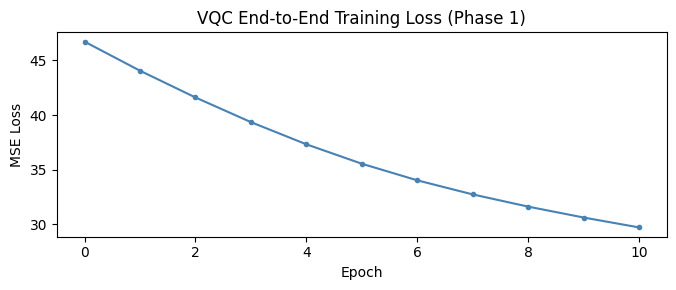

Extracting VQC features (train)...
  200/1000
  400/1000
  600/1000
  800/1000
  1000/1000
Extracting VQC features (test)...
  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000
VQC feature shape -- train: (1000, 10), test: (1000, 10)
=== VQC Result ===
            model      MSE      MAE  Corr
Ridge (raw + VQC) 2.098447 1.099313 0.971
=== Full Comparison (Out-of-Sample) ===
              model      MSE      MAE   Corr
  Ridge (raw + VQC) 2.098447 1.099313 0.9710
Lasso (raw + Angle) 2.439622 1.146400 0.9662
Ridge (raw + Angle) 2.770165 1.158236 0.9620
  Ridge (raw + IQP) 3.080123 1.338836 0.9571
  Lasso (raw + IQP) 3.080823 1.342156 0.9571
   Lasso (raw + ZZ) 3.442248 1.324814 0.9518
   Ridge (raw + ZZ) 3.459894 1.324447 0.9516


,model,MSE,MAE,Corr
0,Ridge (raw + VQC),2.098447,1.099313,0.9710
1,Lasso (raw + Angle),2.439622,1.146400,0.9662
2,Ridge (raw + Angle),2.770165,1.158236,0.9620
3,Ridge (raw + IQP),3.080123,1.338836,0.9571
4,Lasso (raw + IQP),3.080823,1.342156,0.9571
5,Lasso (raw + ZZ),3.442248,1.324814,0.9518
6,Ridge (raw + ZZ),3.459894,1.324447,0.9516


In [ ]:
# -- Phase 1 complete: VQC weights trained end-to-end in cell above -----------
# Plot training loss curve
plt.figure(figsize=(7, 3))
plt.plot(losses, marker="o", markersize=3, linewidth=1.5, color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("VQC End-to-End Training Loss (Phase 1)")
plt.tight_layout()
plt.show()

# -- Phase 2: Freeze weights, extract features, fit Ridge regression ----------
# Use trained weights in inference mode (no gradients needed)
weights_frozen = pnp.array(weights, requires_grad=False)

print("Extracting VQC features (train)...")
VQC_train = []
for i, x in enumerate(X_train_q):
    result = variational_circuit(pnp.array(x, requires_grad=False), weights_frozen)
    VQC_train.append(np.array(result))
    if (i + 1) % 200 == 0:
        print(f"  {i + 1}/{len(X_train_q)}")
VQC_train = np.array(VQC_train)

print("Extracting VQC features (test)...")
VQC_test = []
for i, x in enumerate(X_test_q):
    result = variational_circuit(pnp.array(x, requires_grad=False), weights_frozen)
    VQC_test.append(np.array(result))
    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(X_test_q)}")
VQC_test = np.array(VQC_test)


In [51]:

# Each sample: 4 single-qubit <Z_i> + 6 pairwise <Z_i Z_j> = 10 features
print(f"VQC feature shape -- train: {VQC_train.shape}, test: {VQC_test.shape}")

# -- Combine raw standardized features + VQC features ------------------------
X_tr_vqc = np.hstack([X_train_s, VQC_train])
X_te_vqc  = np.hstack([X_test_s,  VQC_test])

scaler_vqc = StandardScaler()
X_tr_vqc = scaler_vqc.fit_transform(X_tr_vqc)
X_te_vqc  = scaler_vqc.transform(X_te_vqc)

ridge_vqc = Ridge(alpha=1.0).fit(X_tr_vqc, y_train)
pred_vqc  = ridge_vqc.predict(X_te_vqc)

lasso_vqc = Lasso(alpha=0.01).fit(X_tr_vqc, y_train)
pred_vqc_lasso = lasso_vqc.predict(X_te_vqc)

vqc_result_ridge = evaluate_model(y_test, pred_vqc, "Ridge (raw + VQC)")
vqc_result_lasso = evaluate_model(y_test, pred_vqc_lasso, "Lasso (raw + VQC)")

# -- Full comparison ----------------------------------------------------------
results_vqc_df = pd.concat(
    [results_df, pd.DataFrame([vqc_result_ridge, vqc_result_lasso])],
    ignore_index=True
).sort_values("MSE").reset_index(drop=True)

# check the number of features that lasso kept non-zero
n_nonzero = np.sum(lasso_vqc.coef_ != 0)
print(f"\nLasso selected {n_nonzero} features out of {X_tr_vqc.shape[1]} total features.")
results_vqc_df

VQC feature shape -- train: (1000, 10), test: (1000, 10)

Lasso selected 12 features out of 14 total features.


,model,MSE,MAE,Corr
0,Ridge (raw + VQC),2.098447,1.099313,0.9710
1,Lasso (raw + VQC),2.166113,1.107835,0.9700
2,Lasso (raw + Angle),2.439622,1.146400,0.9662
3,Ridge (raw + Angle),2.770165,1.158236,0.9620
4,Ridge (raw + IQP),3.080123,1.338836,0.9571
5,Lasso (raw + IQP),3.080823,1.342156,0.9571
6,Lasso (raw + ZZ),3.442248,1.324814,0.9518
7,Ridge (raw + ZZ),3.459894,1.324447,0.9516


In [49]:
baseline_df.sort_values("MSE").reset_index(drop=True)

,model,MSE,MAE,Corr
0,Lasso (poly deg=2),2.328711,1.131164,0.9677
1,Ridge (poly deg=2),2.500038,1.134690,0.9653
2,LR (poly deg=2),2.539323,1.133970,0.9647
3,LR (raw features),4.972108,1.698632,0.9297


#### 6.2 Quantum Reservoir Computing

- **What it does**: Uses a *random*, untrained quantum circuit as a fixed nonlinear feature extractor. Only the classical readout layer is trained.
- **Key idea**: Analogous to classical echo-state networks - the quantum circuit provides a rich, high-dimensional nonlinear transformation without needing gradient-based optimization. Different random seeds give different feature spaces; you can ensemble multiple reservoirs cheaply.
- **Paper**: Fujii & Nakajima, "Harnessing Disordered-Ensemble Quantum Dynamics for Machine Learning," *PRA* 96, 042306 (2017)

In [17]:
# Experiment with hybrid workflows
#
# Ideas to try:
# 1. Train VQC with more epochs and larger training set
# 2. Change VQC architecture: more layers, different entangling patterns
# 3. Vary reservoir parameters: n_layers, n_reservoirs, different seeds
# 4. Combine reservoir features with quantum kernel (use reservoir features as
#    input to a classical RBF kernel)
# NOTE: These are to guide your ideas, and not restrain your implementation. We are looking for rigorous comparisons, you can be creative with your feature engineering approach as you like

In [53]:
# Quantum Reservoir Computing
# Multiple random circuits as fixed feature extractors

def create_reservoir_circuit(n_qubits, seed):
    """Create a random reservoir circuit with a unique seed."""
    rng = np.random.default_rng(seed)
    
    dev_res = qml.device("default.qubit", wires=n_qubits)
    
    # Random fixed parameters
    n_layers = 3
    random_weights = pnp.array(
        rng.uniform(0, 2 * np.pi, size=(n_layers, n_qubits, 3)),
        requires_grad=False
    )
    
    @qml.qnode(dev_res)
    def reservoir(x):
        for layer in range(n_layers):
            # Encode data
            for i in range(n_qubits):
                qml.RY(x[i % len(x)], wires=i)
            
            # Random fixed rotations
            for i in range(n_qubits):
                qml.RX(random_weights[layer, i, 0], wires=i)
                qml.RY(random_weights[layer, i, 1], wires=i)
                qml.RZ(random_weights[layer, i, 2], wires=i)
            
            # Entanglement
            for i in range(n_qubits):
                qml.CNOT(wires=[i, (i + 1) % n_qubits])
        
        single = [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
        pairs = [
            qml.expval(qml.PauliZ(i) @ qml.PauliZ(j))
            for i in range(n_qubits) for j in range(i + 1, n_qubits)
        ]
        return single + pairs
    
    return reservoir


def extract_reservoir_features(X, n_reservoirs=3, n_qubits=4, label="reservoir"):
    """
    Run data through multiple random reservoir circuits
    and concatenate all their features.
    """
    # Create multiple reservoirs with different random seeds
    reservoirs = [create_reservoir_circuit(n_qubits, seed=s) for s in range(n_reservoirs)]
    
    all_features = []
    for i, x in enumerate(X):
        sample_features = []
        for res in reservoirs:
            result = res(x)
            sample_features.extend(result)
        all_features.append(sample_features)
        if (i + 1) % 500 == 0:
            print(f"  {label}: processed {i + 1}/{len(X)} samples")
    
    return np.array(all_features)


# Extract reservoir features
print("Extracting reservoir features (3 reservoirs)...")
RES_train = extract_reservoir_features(X_train_q, n_reservoirs=3, label="res train")
RES_test = extract_reservoir_features(X_test_q, n_reservoirs=3, label="res test")

print(f"Reservoir features shape: {RES_train.shape}")
# Should be (10000, 30) — 10 features per reservoir × 3 reservoirs
results_reservoir = []
# Combine, standardize, evaluate
X_tr_r = np.hstack([X_train_s, RES_train])
X_te_r = np.hstack([X_test_s, RES_test])
scaler_r = StandardScaler()
X_tr_r = scaler_r.fit_transform(X_tr_r)
X_te_r = scaler_r.transform(X_te_r)

ridge_r = Ridge(alpha=1.0).fit(X_tr_r, y_train)
pred_r = ridge_r.predict(X_te_r)
results_reservoir.append(evaluate_model(y_test, pred_r, "Ridge (raw + Reservoir x3)"))

# Also try Lasso to see which features matter
lasso_r = Lasso(alpha=0.01).fit(X_tr_r, y_train)
pred_lasso_r = lasso_r.predict(X_te_r)
results_reservoir.append(evaluate_model(y_test, pred_lasso_r, "Lasso (raw + Reservoir x3)"))

print(pd.DataFrame(results_reservoir).to_string(index=False))

Extracting reservoir features (3 reservoirs)...
  res train: processed 500/1000 samples
  res train: processed 1000/1000 samples
  res test: processed 500/1000 samples
  res test: processed 1000/1000 samples
Reservoir features shape: (1000, 30)
                     model      MSE      MAE   Corr
Ridge (raw + Reservoir x3) 1.448784 0.914723 0.9800
Lasso (raw + Reservoir x3) 1.609721 0.968154 0.9777


c:\Users\Sneez\Desktop\Computer Science\Competition\YQuantum\YQuantum_AWS_Challenge\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.365e+01, tolerance: 4.112e+00
  model = cd_fast.enet_coordinate_descent(


### Extracting Features from Quantum States

Once data is encoded into a quantum state, we need to *extract* quantum-augmented features from it. Two main approaches:

1. **Expectation values**: Measure observables (Pauli-Z, X, Y or products) on each qubit. Each gives a real number in [-1, 1]. With *n* qubits you get *n* features per observable type.

2. **Probabilities**: Measure the probability of each computational basis state. With *n* qubits this gives 2ⁿ features (exponential — potentially richer but expensive). n qubits will result in 2ⁿ features, which could lead to overfitting in the regression model




## 8. Dimensionality Reduction
To deal with overfitting after augmented features, you can also employ dimensionality reduction tools within your model/circuit (Regularization).

## 9. Evaluation
Collect results from your implemented methods and visualize side-by-side. Remember: the challenge values **rigorous out-of-sample evaluation** over raw performance numbers.


## 10. Real World Scenario - Adapting to Real Stock Data

The second task requires you to work with **actual S&P 500 data**. Refer the challenge handout

NOTE: Make sure there is no data leaks between training and testing data when implementing Walk-forward backtesting.

---
## 11.  Further Reading - Additional Quantum Methods [Experimental]

The methods below are for the purpose of completion of the challenge statement. You are not required to implement these methods as they are for your understanding of the broader landscape.


#### Quantum Random Kitchen Sinks

- **What it does**: Approximates a quantum kernel via random features — analogous to classical random Fourier features for the RBF kernel - without building the full N×N kernel matrix.
- **Key idea**: Instead of computing all O(N²) kernel entries, generate a fixed set of random quantum feature vectors. Their inner products approximate the true quantum kernel. Scales linearly with dataset size rather than quadratically. The reservoir computing approach above is closely related.
- **Composed of**: Random parameterized circuits → Measurement → Classical feature vector → Linear model
- **When to use**: When the dataset is too large for full kernel matrix computation but you want the expressiveness of a quantum kernel.
- **Paper**: Wilson et al., "Quantum Kitchen Sinks: An Algorithm for Machine Learning on Near-Term Quantum Computers," arXiv:1806.08321 (2018)



#### QAOA-Inspired Feature Maps

- **What it does**: Borrows the QAOA circuit structure — alternating problem and mixer Hamiltonians — as a feature map where the problem Hamiltonian encodes the data.
- **Key idea**: QAOA circuits carry an inductive bias toward combinatorial structure. Encoding financial features into the problem Hamiltonian gives a feature map with a fundamentally different algebraic form than ZZ or IQP maps, potentially capturing different correlations.
- **Composed of**: Alternating layers exp(−iγ·C(x)) → exp(−iβ·B), where C(x) is a cost Hamiltonian parameterized by the data
- **When to use**: Experimental — worth trying if ZZ/IQP maps show no improvement.
- **Paper**: Farhi, Goldstone & Gutmann, "A Quantum Approximate Optimization Algorithm," arXiv:1411.4028 (2014)


#### Quantum Convolutional Neural Network (QCNN)

- **What it does**: Applies the CNN paradigm to quantum circuits — local parameterized gates act on neighboring qubits (convolution), followed by qubit measurement and discard (pooling) to progressively reduce dimensionality.
- **Key idea**: Each convolutional layer captures local qubit correlations; pooling layers reduce active qubits and suppress barren plateaus. The hierarchical structure mirrors classical CNNs and makes the circuit more noise-resilient.
- **Composed of**: Convolutional layer (2-qubit parameterized gates) → Pooling (measure and discard half the qubits) → Repeat → Readout
- **When to use**: When features have sequential or spatial structure — e.g., ordered time-series lags, price features at different lookback horizons.
- **Paper**: Cong, Choi & Lukin, "Quantum convolutional neural networks," *Nature Physics* 15, 1273–1278 (2019)


#### Quantum Transfer Learning

- **What it does**: Uses a pre-trained classical neural network for initial feature extraction, then routes the compressed representation into a variational quantum circuit for final processing.
- **Key idea**: Classical networks handle high-dimensional, noisy input well. The quantum circuit then operates on a manageable feature count (matching qubit count), potentially capturing correlations the classical network misses. Practically: train a classical autoencoder to reduce raw features to ~5–10 dimensions, then feed those into a VQC.
- **Composed of**: Classical NN (frozen weights) → Dimensionality reduction layer → VQC → Readout
- **When to use**: Experimental approach, useful when raw features far exceed the qubits available.
- **Paper**: Mari et al., "Transfer learning in hybrid classical-quantum neural networks," *Quantum* 4, 340 (2020)

---
**Good luck! Remember: rigorous methodology and honest conclusions matter more than beating the baseline.**